# Swiss Food Retail Dataset Report

This notebook documents the acquisition, validation, and analysis workflow for the Swiss food retail dataset built from OpenStreetMap exports.

It covers three layers:
- `supermarket_core`: Migros, Coop, Denner, Lidl, ALDI SUISSE
- `supermarket_secondary`: Manor Food, Volg, SPAR
- `convenience`: migrolino, Coop Pronto, avec


In [1]:
import colorsys
import json
import subprocess
import sys
from pathlib import Path

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from shapely.geometry import shape

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 140


def find_scripts_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "data" / "scripts"]
    for candidate in candidates:
        if (candidate / "fetch_swiss_supermarkets.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/scripts directory from the current working directory.")


SCRIPTS_DIR = find_scripts_dir()
PROJECT_ROOT = SCRIPTS_DIR.parents[1]
OUTPUT_DIR = PROJECT_ROOT / "data" / "raw_data" / "supermarkets"
BOUNDARY_PATH = PROJECT_ROOT / "data" / "raw_data" / "swiss_boundary.geojson"
FETCH_SCRIPT = SCRIPTS_DIR / "fetch_swiss_supermarkets.py"

LAYER_ORDER = ["supermarket_core", "supermarket_secondary", "convenience"]
BRAND_ORDER = [
    "Migros",
    "Coop",
    "Denner",
    "Lidl",
    "ALDI SUISSE",
    "Manor Food",
    "Volg",
    "SPAR",
    "migrolino",
    "Coop Pronto",
    "avec",
]

BRAND_COLORS = {
    "Migros": "#F28E2B",
    "Coop": "#4E79A7",
    "Denner": "#E15759",
    "Lidl": "#76B7B2",
    "ALDI SUISSE": "#B07AA1",
    "Manor Food": "#9C755F",
    "Volg": "#59A14F",
    "SPAR": "#7A9E3A",
    "migrolino": "#17BECF",
    "Coop Pronto": "#D37295",
    "avec": "#B6992D",
}

def quantity_scaled_color(hex_color: str, intensity: float) -> str:
    intensity = max(0.0, min(1.0, float(intensity)))
    r, g, b = mcolors.to_rgb(hex_color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    scaled_s = min(1.0, 0.35 + intensity * 0.65)
    scaled_l = max(0.28, 0.78 - intensity * 0.33)
    nr, ng, nb = colorsys.hls_to_rgb(h, scaled_l, scaled_s)
    return mcolors.to_hex((nr, ng, nb))

display(Markdown(
    f"**Project root:** `{PROJECT_ROOT}`  \n"
    f"**Output directory:** `{OUTPUT_DIR}`  \n"
    f"**Fetch script:** `{FETCH_SCRIPT}`"
))


**Project root:** `/Users/bruce12138/com480/SwissReach`  
**Output directory:** `/Users/bruce12138/com480/SwissReach/data/raw_data/supermarkets`  
**Fetch script:** `/Users/bruce12138/com480/SwissReach/data/scripts/fetch_swiss_supermarkets.py`

## 1. Optional data acquisition

Set `RUN_FETCH = True` to refresh the local CSV/JSON exports before analysis.
The notebook calls the project script directly, so the same brand logic is reused.

In [2]:
RUN_FETCH = False
FETCH_BRANDS = [
    "migros",
    "coop",
    "denner",
    "lidl",
    "aldi",
    "manor_food",
    "volg",
    "spar",
    "migrolino",
    "coop_pronto",
    "avec",
]

if RUN_FETCH:
    cmd = [sys.executable, str(FETCH_SCRIPT), "--brands", *FETCH_BRANDS]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Skipping fetch. Set RUN_FETCH = True to refresh local exports.")


Skipping fetch. Set RUN_FETCH = True to refresh local exports.


## 2. Load brand exports

In [3]:
brand_files = sorted(OUTPUT_DIR.glob("*_stores.csv"))
if not brand_files:
    raise FileNotFoundError(f"No brand exports found in {OUTPUT_DIR}. Run the fetch cell first.")

frames = []
for path in brand_files:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    frames.append(df)

retail = pd.concat(frames, ignore_index=True)
retail["lat"] = pd.to_numeric(retail["lat"], errors="coerce")
retail["lon"] = pd.to_numeric(retail["lon"], errors="coerce")
retail["layer"] = pd.Categorical(retail["layer"], categories=LAYER_ORDER, ordered=True)
retail["brand"] = pd.Categorical(retail["brand"], categories=BRAND_ORDER, ordered=True)

address_cols = ["street", "house_number", "postcode", "city"]
retail["has_structured_address"] = (
    retail[address_cols]
    .fillna("")
    .astype(str)
    .apply(lambda col: col.str.strip())
    .ne("")
    .any(axis=1)
)

display(retail.head())
print(f"Loaded {len(retail):,} rows from {len(brand_files)} brand exports")


,brand,brand_slug,group,layer,retail_format,name,shop,street,house_number,postcode,city,canton,country,address,osm_brand,osm_operator,lat,lon,osm_type,osm_id,website,phone,opening_hours,source_url,source_file,has_structured_address
0,ALDI SUISSE,aldi,ALDI SUISSE,supermarket_core,supermarket,Aldi,supermarket,NaN,NaN,NaN,NaN,NaN,CH,CH,ALDI,Aldi Suisse,47.246485,8.646440,way,31827536,https://www.aldi-suisse.ch/,NaN,Mo-Sa 07:30-20:00; PH off,https://www.openstreetmap.org/way/31827536,aldi_stores.csv,False
1,ALDI SUISSE,aldi,ALDI SUISSE,supermarket_core,supermarket,ALDI,supermarket,Leuzigenstrasse,4,NaN,NaN,NaN,CH,"Leuzigenstrasse 4, CH",ALDI,NaN,47.192988,7.407125,way,55957036,NaN,+41 32 653 35 85,Mo-Th 08:00-18:30; Fr 08:00-20:00; Sa 08:00-18...,https://www.openstreetmap.org/way/55957036,aldi_stores.csv,True
2,ALDI SUISSE,aldi,ALDI SUISSE,supermarket_core,supermarket,Aldi,supermarket,Hornblick,5,NaN,NaN,NaN,CH,"Hornblick 5, CH",ALDI,Aldi Suisse,47.489097,8.244171,way,79175799,https://www.aldi-suisse.ch/,NaN,Mo-Sa 07:30-20:00; PH off,https://www.openstreetmap.org/way/79175799,aldi_stores.csv,True
3,ALDI SUISSE,aldi,ALDI SUISSE,supermarket_core,supermarket,Aldi,supermarket,Rue de Lausanne,47,NaN,NaN,NaN,CH,"Rue de Lausanne 47, CH",Aldi,NaN,46.516285,6.505677,way,102576467,NaN,+41 21 803 46 49,Mo-Th 08:00-18:45; Fr 08:00-20:00; Sa 08:00-18...,https://www.openstreetmap.org/way/102576467,aldi_stores.csv,True
4,ALDI SUISSE,aldi,ALDI SUISSE,supermarket_core,supermarket,ALDI,supermarket,NaN,NaN,NaN,NaN,NaN,CH,CH,ALDI,NaN,47.387333,9.274097,way,134097726,NaN,NaN,NaN,https://www.openstreetmap.org/way/134097726,aldi_stores.csv,False


Loaded 4,103 rows from 11 brand exports


## 3. Summary counts by layer, group, and brand

In [4]:
brand_summary = (
    retail.groupby(["layer", "group", "brand"], observed=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(["layer", "rows", "brand"], ascending=[True, False, True])
)

layer_summary = (
    retail.groupby(["layer", "retail_format"], observed=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(["layer", "rows"], ascending=[True, False])
)

display(brand_summary)
display(layer_summary)


,layer,group,brand,rows
12,supermarket_core,Coop,Coop,943
44,supermarket_core,Migros,Migros,743
46,supermarket_core,Migros,Denner,718
4,supermarket_core,ALDI SUISSE,ALDI SUISSE,239
25,supermarket_core,Lidl,Lidl,183
...,...,...,...,...
208,convenience,Lidl,avec,0
219,convenience,Manor,avec,0
230,convenience,Migros,avec,0
241,convenience,SPAR,avec,0


,layer,retail_format,rows
1,supermarket_core,supermarket,2826
0,supermarket_core,convenience,0
3,supermarket_secondary,supermarket,604
2,supermarket_secondary,convenience,0
4,convenience,convenience,673
5,convenience,supermarket,0


## 4. Compare against public benchmark counts

These benchmark figures are rough public references, not strict ground truth. They still help flag obvious OSM undercoverage.

In [5]:
benchmarks = pd.DataFrame([
    {"brand": "Migros", "official_count": 790, "benchmark_date": "2024-12", "benchmark_note": "Migros public statement: just under 790 locations incl. VOI and Migros Partner."},
    {"brand": "Coop", "official_count": 970, "benchmark_date": "2024", "benchmark_note": "Coop annual report retail stores."},
    {"brand": "Denner", "official_count": 880, "benchmark_date": "2026-03", "benchmark_note": "Denner locator says over 880 branches."},
    {"brand": "Lidl", "official_count": 180, "benchmark_date": "2025", "benchmark_note": "Lidl Schweiz says over 180 branches."},
    {"brand": "ALDI SUISSE", "official_count": 247, "benchmark_date": "2025-10", "benchmark_note": "ALDI SUISSE public company milestone count."},
    {"brand": "Manor Food", "official_count": 23, "benchmark_date": "2025", "benchmark_note": "Manor public facts page."},
    {"brand": "Volg", "official_count": 593, "benchmark_date": "2025", "benchmark_note": "Volg company page store count."},
    {"brand": "SPAR", "official_count": 350, "benchmark_date": "2025", "benchmark_note": "SPAR Schweiz says over 350 stores."},
    {"brand": "migrolino", "official_count": 370, "benchmark_date": "2026-03", "benchmark_note": "migrolino expansion page says over 370 shops."},
    {"brand": "Coop Pronto", "official_count": 320, "benchmark_date": "2026-01", "benchmark_note": "Coop Pronto AG says over 320 shops."},
    {"brand": "avec", "official_count": 360, "benchmark_date": "2026-01", "benchmark_note": "avec public site says around 360 stores."},
])

coverage = (
    retail.groupby("brand", observed=False)
    .size()
    .rename("rows")
    .reset_index()
    .merge(benchmarks, on="brand", how="left")
)
coverage["coverage_pct"] = (coverage["rows"] / coverage["official_count"] * 100).round(1)
coverage = coverage.sort_values("coverage_pct")
display(coverage)


,brand,rows,official_count,benchmark_date,benchmark_note,coverage_pct
5,Manor Food,5,23,2025,Manor public facts page.,21.7
7,SPAR,124,350,2025,SPAR Schweiz says over 350 stores.,35.4
10,avec,155,360,2026-01,avec public site says around 360 stores.,43.1
8,migrolino,276,370,2026-03,migrolino expansion page says over 370 shops.,74.6
9,Coop Pronto,242,320,2026-01,Coop Pronto AG says over 320 shops.,75.6
6,Volg,475,593,2025,Volg company page store count.,80.1
2,Denner,718,880,2026-03,Denner locator says over 880 branches.,81.6
0,Migros,743,790,2024-12,Migros public statement: just under 790 locati...,94.1
4,ALDI SUISSE,239,247,2025-10,ALDI SUISSE public company milestone count.,96.8
1,Coop,943,970,2024,Coop annual report retail stores.,97.2


## 5. Data quality checks

In [6]:
duplicate_mask = retail.duplicated(["brand", "name", "lat", "lon"], keep=False)
outside_bbox_mask = ~(
    retail["lat"].between(45.7, 47.95)
    & retail["lon"].between(5.7, 10.7)
)
zero_coord_mask = (retail["lat"] == 0) | (retail["lon"] == 0)

quality_overview = pd.DataFrame([
    {"metric": "total_rows", "value": int(len(retail))},
    {"metric": "duplicate_brand_name_coord", "value": int(duplicate_mask.sum())},
    {"metric": "zero_coordinate_rows", "value": int(zero_coord_mask.sum())},
    {"metric": "outside_swiss_bbox_rows", "value": int(outside_bbox_mask.sum())},
    {"metric": "rows_without_structured_address", "value": int((~retail['has_structured_address']).sum())},
])

address_quality = (
    retail.groupby("brand", observed=False)
    .agg(
        rows=("brand", "size"),
        missing_structured_address=("has_structured_address", lambda s: int((~s).sum())),
    )
    .reset_index()
)
address_quality["missing_structured_address_share"] = (
    address_quality["missing_structured_address"] / address_quality["rows"]
).round(3)
address_quality = address_quality.sort_values("missing_structured_address_share", ascending=False)

display(quality_overview)
display(address_quality)


,metric,value
0,total_rows,4103
1,duplicate_brand_name_coord,0
2,zero_coordinate_rows,0
3,outside_swiss_bbox_rows,0
4,rows_without_structured_address,1503


,brand,rows,missing_structured_address,missing_structured_address_share
10,avec,155,91,0.587
2,Denner,718,362,0.504
6,Volg,475,216,0.455
1,Coop,943,395,0.419
5,Manor Food,5,2,0.400
9,Coop Pronto,242,96,0.397
4,ALDI SUISSE,239,62,0.259
0,Migros,743,185,0.249
3,Lidl,183,40,0.219
8,migrolino,276,50,0.181


## 6. Geospatial validation and maps

,layer,inside_switzerland,rows
0,supermarket_core,True,2826
1,supermarket_secondary,True,604
2,convenience,True,673


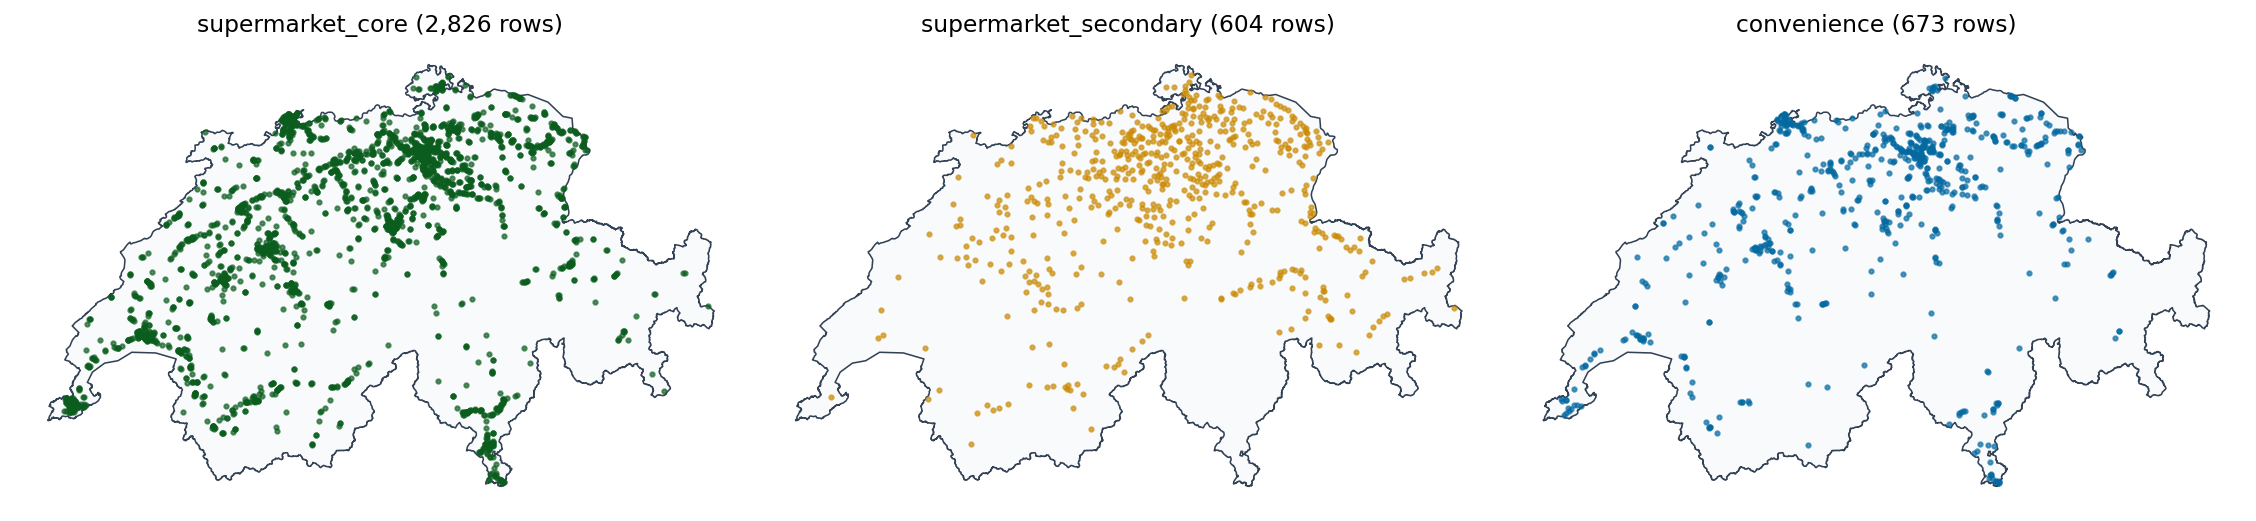

In [7]:
boundary_json = json.loads(BOUNDARY_PATH.read_text())
boundary = gpd.GeoDataFrame(
    {"name": ["Switzerland"]},
    geometry=[shape(boundary_json["feature"]["geometry"])],
    crs="EPSG:2056",
)

points = gpd.GeoDataFrame(
    retail.copy(),
    geometry=gpd.points_from_xy(retail["lon"], retail["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:2056")

swiss_geom = boundary.geometry.iloc[0]
points["inside_switzerland"] = points.geometry.within(swiss_geom) | points.geometry.touches(swiss_geom)
display(points.groupby(["layer", "inside_switzerland"], observed=False).size().rename("rows").reset_index())

layer_colors = {
    "supermarket_core": "#0b5d1e",
    "supermarket_secondary": "#ca8a04",
    "convenience": "#0369a1",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, layer in zip(axes, LAYER_ORDER):
    boundary.plot(ax=ax, color="#f8fafc", edgecolor="#334155", linewidth=0.8)
    subset = points[points["layer"] == layer]
    subset.plot(ax=ax, color=layer_colors[layer], markersize=5, alpha=0.65)
    ax.set_title(f"{layer} ({len(subset):,} rows)")
    ax.set_axis_off()

plt.show()


## 6A. Interactive brand combination explorer

Use the checkboxes below to choose any brand combination. The notebook will recompute counts and redraw a color-coded map for the selected set.


In [ ]:
brand_options = [brand for brand in BRAND_ORDER if brand in set(points["brand"].astype(str))]

brand_layer_lookup = (
    retail[["brand", "layer"]]
    .drop_duplicates()
    .assign(brand=lambda df: df["brand"].astype(str), layer=lambda df: df["layer"].astype(str))
    .set_index("brand")["layer"]
    .to_dict()
)

layer_titles = {
    "supermarket_core": "Core Supermarkets",
    "supermarket_secondary": "Secondary Supermarkets",
    "convenience": "Convenience",
}

layer_to_brands = {
    layer: [brand for brand in brand_options if brand_layer_lookup.get(brand) == layer]
    for layer in LAYER_ORDER
}

brand_checks = {
    brand: widgets.Checkbox(
        value=True,
        description=brand,
        indent=False,
        layout=widgets.Layout(width="170px"),
    )
    for brand in brand_options
}

marker_size = widgets.IntSlider(
    value=1, min=1, max=10, step=2, description="Marker Size",
    continuous_update=False, style={"description_width": "initial"}
)

alpha_slider = widgets.FloatSlider(
    value=0.7, min=0.2, max=1.0, step=0.1, description="Point Alpha",
    continuous_update=False, style={"description_width": "initial"}
)

def selected_brands_from_checks():
    return [brand for brand, checkbox in brand_checks.items() if checkbox.value]


def set_brand_selection(brands_to_keep):
    brands_to_keep = set(brands_to_keep)
    for brand, checkbox in brand_checks.items():
        checkbox.value = brand in brands_to_keep


select_all_btn = widgets.Button(description="Select All", button_style="success")
clear_all_btn = widgets.Button(description="Clear All")
core_btn = widgets.Button(description="Core Only")
secondary_btn = widgets.Button(description="Secondary Only")
convenience_btn = widgets.Button(description="Convenience Only")

select_all_btn.on_click(lambda _: set_brand_selection(brand_options))
clear_all_btn.on_click(lambda _: set_brand_selection([]))
core_btn.on_click(lambda _: set_brand_selection(layer_to_brands["supermarket_core"]))
secondary_btn.on_click(lambda _: set_brand_selection(layer_to_brands["supermarket_secondary"]))
convenience_btn.on_click(lambda _: set_brand_selection(layer_to_brands["convenience"]))

button_row = widgets.HBox(
    [select_all_btn, clear_all_btn, core_btn, secondary_btn, convenience_btn],
    layout=widgets.Layout(flex_flow="row wrap", gap="8px"),
)

layer_sections = []
for layer in LAYER_ORDER:
    layer_checks = [brand_checks[brand] for brand in layer_to_brands[layer]]
    grid = widgets.GridBox(
        layer_checks,
        layout=widgets.Layout(
            grid_template_columns="repeat(2, minmax(160px, 1fr))",
            gap="4px 12px",
        ),
    )
    section = widgets.VBox(
        [widgets.HTML(f"<b>{layer_titles[layer]}</b>"), grid],
        layout=widgets.Layout(border="1px solid #d6dee8", padding="10px", margin="0 0 8px 0"),
    )
    layer_sections.append(section)

control_panel = widgets.VBox(
    [
        widgets.HTML("<h4 style='margin:0 0 6px 0;'>Brand Filters</h4>"),
        button_row,
        *layer_sections,
        marker_size,
        alpha_slider,
    ],
    layout=widgets.Layout(width="100%"),
)

interactive_output = widgets.Output()

def render_brand_combo(selected_brands, marker_size, alpha):
    if not selected_brands:
        display(Markdown("Select at least one brand to render the interactive view."))
        return

    brand_strings = points["brand"].astype(str)
    subset = points.loc[brand_strings.isin(selected_brands)].copy()
    subset["brand_str"] = subset["brand"].astype(str)
    subset["layer_str"] = subset["layer"].astype(str)

    total_rows = len(subset)
    unique_brands = subset["brand_str"].nunique()
    layer_counts = subset.groupby("layer_str").size().reindex(LAYER_ORDER, fill_value=0)
    summary_md = (
        f"**Selected rows:** {total_rows:,}  \n"
        f"**Selected brands:** {unique_brands}  \n"
        f"**Core:** {int(layer_counts.get('supermarket_core', 0)):,} | "
        f"**Secondary:** {int(layer_counts.get('supermarket_secondary', 0)):,} | "
        f"**Convenience:** {int(layer_counts.get('convenience', 0)):,}"
    )
    display(Markdown(summary_md))

    brand_counts = (
        subset.groupby(["layer_str", "brand_str"], observed=False)
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(["layer_str", "rows", "brand_str"], ascending=[True, False, True])
    )
    display(brand_counts)

    counts_for_plot = (
        subset.groupby("brand_str")
        .size()
        .sort_values(ascending=False)
    )
    count_min = counts_for_plot.min()
    count_max = counts_for_plot.max()

    def brand_color_for_count(brand_name):
        base = BRAND_COLORS.get(brand_name, "#475569")
        count = counts_for_plot.loc[brand_name]
        if count_max == count_min:
            intensity = 1.0
        else:
            intensity = (count - count_min) / (count_max - count_min)
        return quantity_scaled_color(base, intensity)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    boundary.plot(ax=axes[0], color="#f8fafc", edgecolor="#334155", linewidth=0.8)
    for brand in counts_for_plot.index:
        brand_subset = subset[subset["brand_str"] == brand]
        if brand_subset.empty:
            continue
        brand_subset.plot(
            ax=axes[0],
            color=brand_color_for_count(brand),
            markersize=marker_size,
            alpha=alpha,
            label=f"{brand} ({len(brand_subset):,})",
        )
    axes[0].set_title("Selected brands in Switzerland")
    axes[0].set_axis_off()
    axes[0].legend(loc="upper left", fontsize=8, frameon=True, ncol=1)

    bars = axes[1].barh(
        counts_for_plot.index,
        counts_for_plot.values,
        color=[brand_color_for_count(brand) for brand in counts_for_plot.index],
    )
    axes[1].invert_yaxis()
    axes[1].set_title("Rows per selected brand")
    axes[1].set_xlabel("Rows")
    axes[1].grid(axis="x", alpha=0.15)
    axes[1].bar_label(bars, fmt="%d", padding=4, fontsize=9)

    plt.show()

def refresh_brand_combo(_=None):
    with interactive_output:
        interactive_output.clear_output(wait=True)
        render_brand_combo(selected_brands_from_checks(), marker_size.value, alpha_slider.value)

for checkbox in brand_checks.values():
    checkbox.observe(refresh_brand_combo, names="value")
marker_size.observe(refresh_brand_combo, names="value")
alpha_slider.observe(refresh_brand_combo, names="value")

refresh_brand_combo()

display(control_panel)
display(interactive_output)


Output()

## 7. Coverage and completeness charts

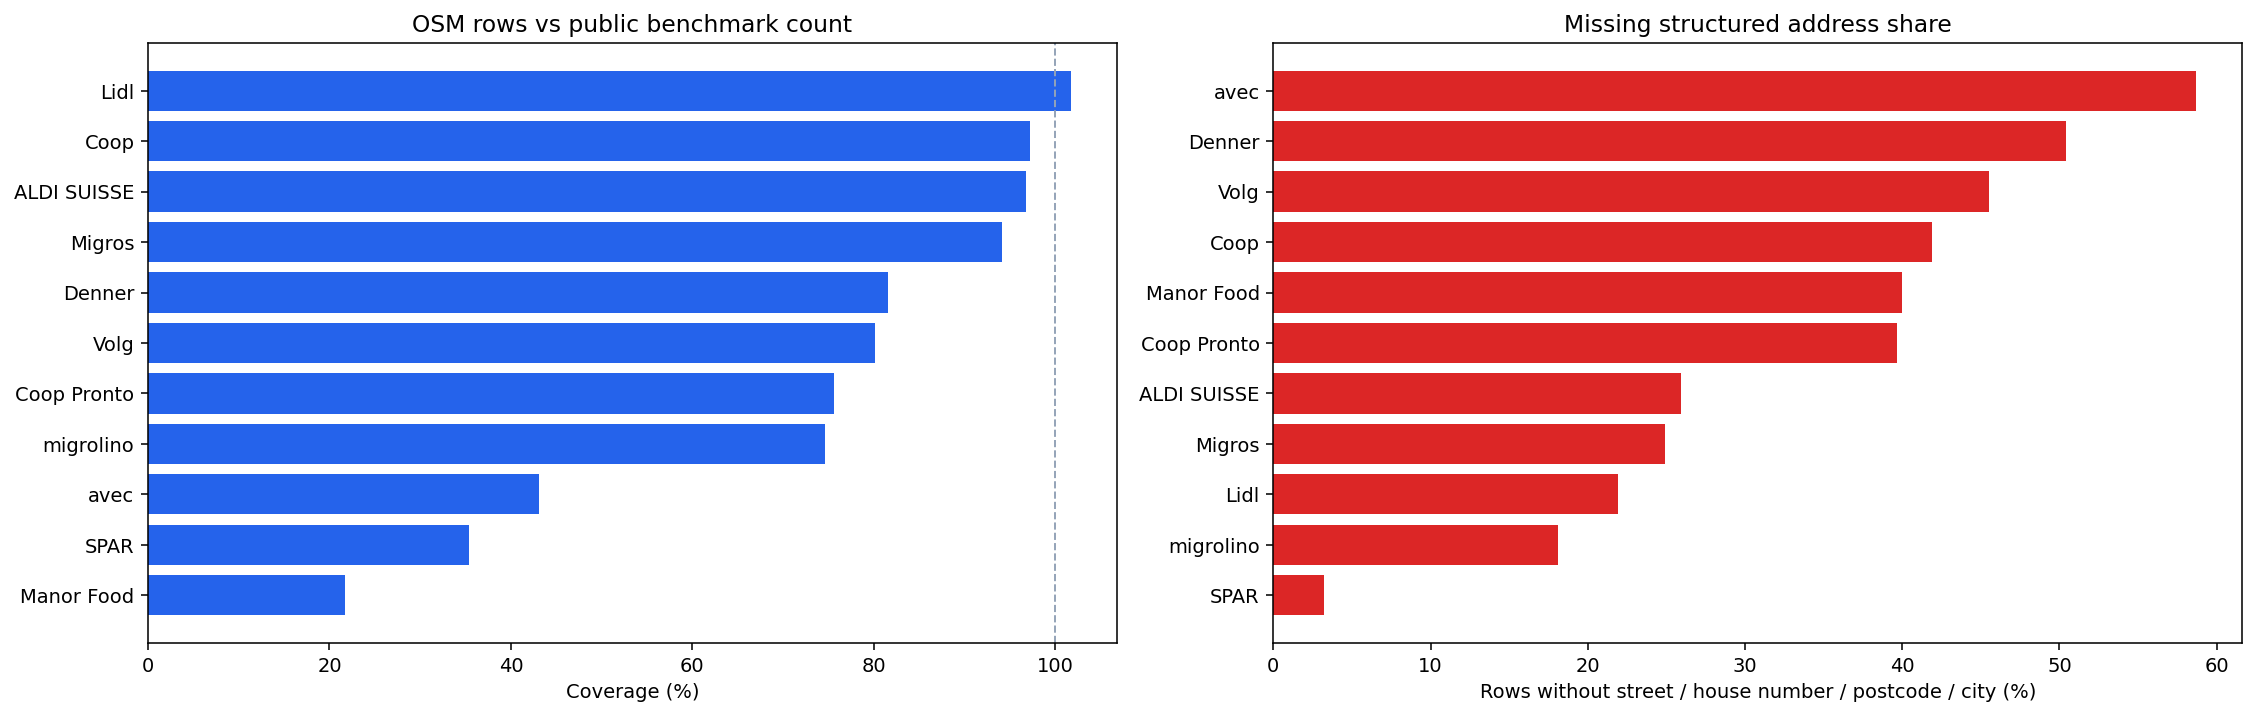

In [9]:
coverage_plot = coverage.dropna(subset=["coverage_pct"]).sort_values("coverage_pct")
address_plot = address_quality.sort_values("missing_structured_address_share")

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

axes[0].barh(coverage_plot["brand"].astype(str), coverage_plot["coverage_pct"], color="#2563eb")
axes[0].axvline(100, color="#94a3b8", linestyle="--", linewidth=1)
axes[0].set_title("OSM rows vs public benchmark count")
axes[0].set_xlabel("Coverage (%)")

axes[1].barh(address_plot["brand"].astype(str), address_plot["missing_structured_address_share"] * 100, color="#dc2626")
axes[1].set_title("Missing structured address share")
axes[1].set_xlabel("Rows without street / house number / postcode / city (%)")

plt.show()


## 8. Narrative summary

In [10]:
low_coverage = coverage.dropna(subset=["coverage_pct"]).query("coverage_pct < 80").sort_values("coverage_pct")
high_missing = address_quality.query("missing_structured_address_share > 0.4").sort_values("missing_structured_address_share", ascending=False)
inside_failures = int((~points["inside_switzerland"]).sum())

summary_lines = [
    f"Total rows: **{len(retail):,}** across **{retail['brand'].nunique()}** brands.",
    f"Rows by layer: core **{(retail['layer'] == 'supermarket_core').sum():,}**, secondary **{(retail['layer'] == 'supermarket_secondary').sum():,}**, convenience **{(retail['layer'] == 'convenience').sum():,}**.",
    f"Points outside Swiss national boundary: **{inside_failures}**.",
]

if not low_coverage.empty:
    offenders = ", ".join(f"{row.brand} ({row.coverage_pct:.1f}%)" for row in low_coverage.itertuples())
    summary_lines.append(f"Brands with clearly low benchmark coverage: **{offenders}**.")

if not high_missing.empty:
    weak_addresses = ", ".join(
        f"{row.brand} ({row.missing_structured_address_share * 100:.1f}% missing)"
        for row in high_missing.itertuples()
    )
    summary_lines.append(f"Brands with weak structured address coverage: **{weak_addresses}**.")

display(Markdown("\n\n".join(f"- {line}" for line in summary_lines)))


- Total rows: **4,103** across **11** brands.

- Rows by layer: core **2,826**, secondary **604**, convenience **673**.

- Points outside Swiss national boundary: **0**.

- Brands with clearly low benchmark coverage: **Manor Food (21.7%), SPAR (35.4%), avec (43.1%), migrolino (74.6%), Coop Pronto (75.6%)**.

- Brands with weak structured address coverage: **avec (58.7% missing), Denner (50.4% missing), Volg (45.5% missing), Coop (41.9% missing)**.